# 03 — LTspice vs analytical

Created with Grok Build

Batch-runs a generated LTspice `.cir` for Fig. 8-6, compares `.meas`
metrics, and overlays the **full AC Bode** from the LTspice `.raw` file
against the analytical $H_{\mathrm{vin}}(j\omega)$.

**Custom schematic:** export netlist from your `.asc`, keep or rename `.meas`
statements / node names, and call `ltspice_io.run_ltspice_deck` +
`parse_ltspice_raw_ac` (set `vout_name` / `vin_name` to match your nodes).


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Directory that contains opamp_design/. Works when this notebook is run
# from the standalone repo (repo root or notebooks/) or from this website
# section (the folder that holds these notebooks and opamp_design/).
def _find_project_root() -> Path:
    start = Path.cwd().resolve()
    named = Path("Sections/Electronics/Analog_and_Digital/OPA365_Fig86")
    candidates = [start, *start.parents, start / named]
    if start.name == "notebooks":
        candidates.insert(0, start.parent)
    for cand in candidates:
        if (cand / "opamp_design" / "__init__.py").is_file():
            return cand
    return start

ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from opamp_design.params import CircuitParams, OpampParams, ToleranceSpec, format_eng
from opamp_design import analysis, schematic

# -----------------------------------------------------------------------------
# EDITABLE PARAMETERS — change R/C/tolerances here for what-if studies.
# For a completely different netlist, keep these as documentation of the
# stimulus/supply and drive opamp_design.simulate.run_external_netlist(...)
# with your own .cir instead of the Fig. 8-6 generators.
# -----------------------------------------------------------------------------
R1 = 1.8e3       # ohms
R2 = 19.5e3
R3 = 150e3
C1 = 3.3e-9      # farads
C2 = 47e-12
C3 = 220e-12
R_TOL = 0.001    # 0.1% as fraction
C_TOL = 0.01     # 1% as fraction
V_SUPPLY = 5.0
V_IN_BIAS = 2.5
V_IN_PEAK = 2.5
F_DESIGN = 20e3

p = CircuitParams(
    R1=R1, R2=R2, R3=R3, C1=C1, C2=C2, C3=C3,
    r_tol=ToleranceSpec(R_TOL),
    c_tol=ToleranceSpec(C_TOL),
)
# Operating point overrides
from dataclasses import replace
p = replace(p, op=replace(p.op, v_supply=V_SUPPLY, v_in_bias=V_IN_BIAS,
                          v_in_peak=V_IN_PEAK, f_design_hz=F_DESIGN))

FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print("ROOT =", ROOT)
print("R1..C3 =", p.passive_dict())


ROOT = .
R1..C3 = {'R1': 1800.0, 'R2': 19500.0, 'R3': 150000.0, 'C1': 3.3e-09, 'C2': 4.7e-11, 'C3': 2.2e-10}


In [2]:
from opamp_design.ltspice_io import find_ltspice, simulate_ltspice_ac_bode
from opamp_design.analysis import summary_metrics, transfer_at_s

print("LTspice:", find_ltspice())
m_an = summary_metrics(p)

wd = ROOT / "results" / "ltspice" / "nom_ideal"
meas = {}
lt_ac = None
try:
    # Returns (.meas scalars, full Bode from .raw)
    meas, lt_ac = simulate_ltspice_ac_bode(
        p, workdir=wd, root=ROOT, opamp_model="ideal"
    )
    print("LTspice meas:", {k: meas[k] for k in meas if k in (
        "gain_100hz", "gain_20k", "phase_20k", "fc_3db", "re_20k", "im_20k"
    )})
    print(
        "LTspice AC points:", len(lt_ac.f_hz),
        "f=[{:.4g}, {:.4g}] Hz".format(lt_ac.f_hz[0], lt_ac.f_hz[-1]),
    )
except Exception as e:
    print("LTspice run failed:", e)
    meas, lt_ac = {}, None

rows = [
    {"source": "analytical", "fc_hz": m_an["fc_hz"],
     "gain_100": m_an["passband_gain"], "gain_20k": m_an["gain_at_fdesign"],
     "phase_20k_deg": m_an["phase_at_fdesign_deg"]},
]
if meas:
    rows.append({
        "source": "LTspice ideal",
        "fc_hz": meas.get("fc_3db", float("nan")),
        "gain_100": meas.get("gain_100hz", float("nan")),
        "gain_20k": meas.get("gain_20k", float("nan")),
        "phase_20k_deg": meas.get("phase_20k", float("nan")),
    })
display(pd.DataFrame(rows))

# Bode error metrics on LTspice frequency grid (should be ~numerical noise for ideal model)
if lt_ac is not None:
    h_a = np.array([
        transfer_at_s(1j * 2 * np.pi * fi, p, "vin") for fi in lt_ac.f_hz
    ])
    err_db = lt_ac.mag_db - 20 * np.log10(np.maximum(np.abs(h_a), 1e-30))
    print(f"max |LTspice - analytical| = {np.max(np.abs(err_db)):.3e} dB")
    print(f"RMS error = {np.sqrt(np.mean(err_db**2)):.3e} dB")


LTspice: LTspice.exe


LTspice meas: {'gain_100hz': 0.9999920840720222, 'gain_20k': 0.7005193945512969, 're_20k': -0.1318489158076977, 'im_20k': -0.6879994807721947, 'fc_3db': 19753.3965864, 'phase_20k': -100.84868672835672}
LTspice AC points: 241 f=[10, 1e+07] Hz


,source,fc_hz,gain_100,gain_20k,phase_20k_deg
0,analytical,19766.713183,0.999993,0.700653,-100.861860
1,LTspice ideal,19753.396586,0.999992,0.700519,-100.848687


max |LTspice - analytical| = 3.365e-04 dB
RMS error = 2.691e-05 dB


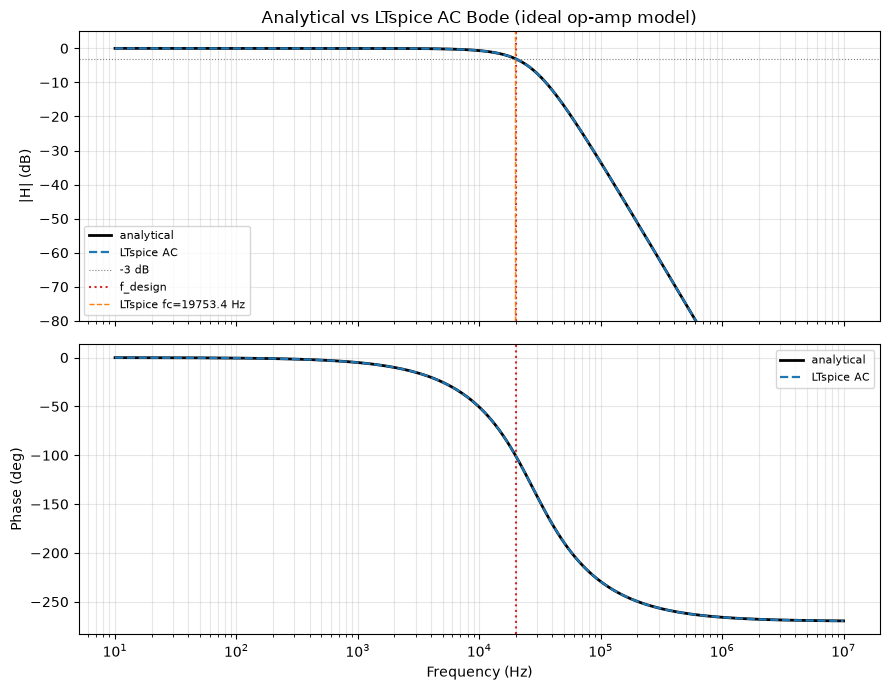

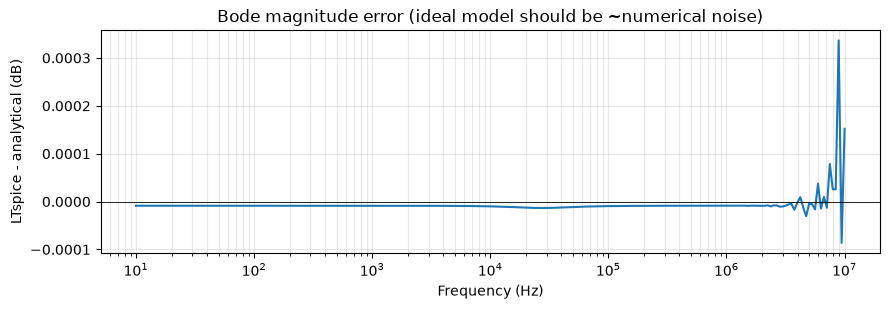

In [3]:
# Overlay analytical H(jw) with full LTspice AC sweep (from .raw)
from opamp_design.analysis import bode

br = bode(p)  # analytical on a dense log grid

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# --- Magnitude ---
axes[0].semilogx(br.f_hz, br.mag_db, "k-", lw=2.0, label="analytical", zorder=2)
if lt_ac is not None:
    axes[0].semilogx(
        lt_ac.f_hz, lt_ac.mag_db, "C0--", lw=1.6, label="LTspice AC", zorder=3
    )
axes[0].axhline(-3, color="gray", ls=":", lw=0.8, label="-3 dB")
axes[0].axvline(p.op.f_design_hz, color="C3", ls=":", label="f_design")
if meas.get("fc_3db"):
    axes[0].axvline(
        meas["fc_3db"], color="C1", ls="--", lw=1.0,
        label=f"LTspice fc={meas['fc_3db']:.1f} Hz",
    )
axes[0].set_ylabel("|H| (dB)")
axes[0].set_title("Analytical vs LTspice AC Bode (ideal op-amp model)")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend(fontsize=8, loc="best")
axes[0].set_ylim(-80, 5)

# --- Phase ---
axes[1].semilogx(
    br.f_hz, br.phase_unwrapped_deg, "k-", lw=2.0, label="analytical", zorder=2
)
if lt_ac is not None:
    axes[1].semilogx(
        lt_ac.f_hz, lt_ac.phase_unwrapped_deg, "C0--", lw=1.6,
        label="LTspice AC", zorder=3,
    )
axes[1].axvline(p.op.f_design_hz, color="C3", ls=":")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Phase (deg)")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend(fontsize=8, loc="best")

fig.tight_layout()
fig.savefig(FIG / "03_ltspice_vs_analytical_bode.png", dpi=150)
plt.show()

# Error subplot (LTspice - analytical) when sweep available
if lt_ac is not None:
    h_a = np.array([
        transfer_at_s(1j * 2 * np.pi * fi, p, "vin") for fi in lt_ac.f_hz
    ])
    err_db = lt_ac.mag_db - 20 * np.log10(np.maximum(np.abs(h_a), 1e-30))
    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.semilogx(lt_ac.f_hz, err_db, color="C0")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("LTspice - analytical (dB)")
    ax.set_title("Bode magnitude error (ideal model should be ~numerical noise)")
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG / "03_ltspice_error_db.png", dpi=150)
    plt.show()
